<a href="https://colab.research.google.com/github/Ananya22-ux/OASIS-INFOBYTE/blob/main/Unveiling_the_Android_App_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob


In [ ]:
# 1. Data Preparation

# Load the dataset
df = pd.read_csv('apps.csv.zip')

In [ ]:
# Display basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB
None


In [ ]:
# Check for missing values
print(df.isnull().sum())

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64


In [ ]:
# Clean and correct data types
df['Price'] = df['Price'].apply(lambda x: float(x.replace('$', '')) if x != 'Free' else 0)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Size'] = df['Size'].apply(lambda x: float(x.replace('M', '')) if 'M' in str(x) else float(x.replace('k', '')) / 1000 if 'k' in str(x) else np.nan)

In [ ]:
# Remove rows with missing values
df = df.dropna()

print("Data preparation completed.")


Data preparation completed.


In [ ]:
# 2. Category Exploration

# Count the number of apps in each category
category_counts = df['Category'].value_counts()

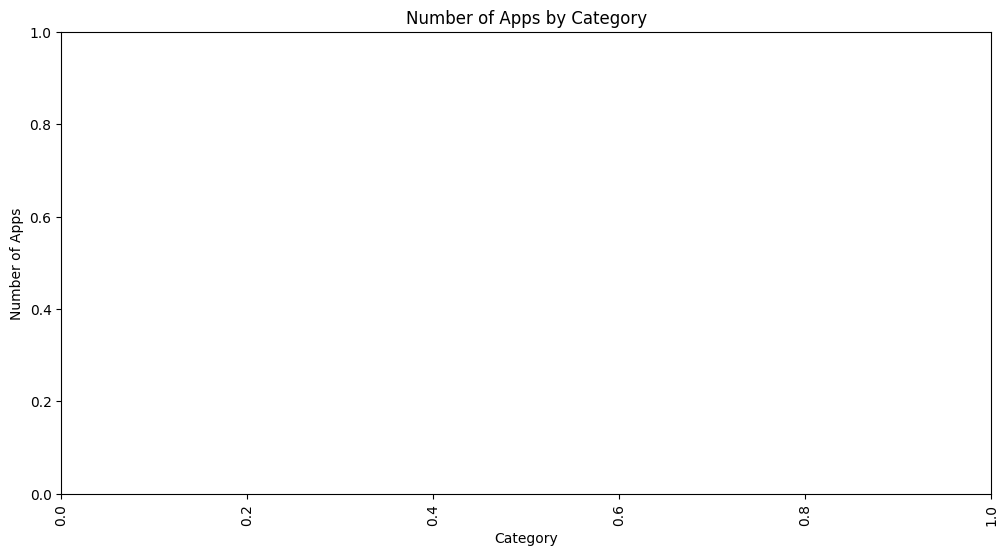

Category exploration completed.


In [ ]:
# Create a bar plot of app categories
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=90)
plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.show()

print("Category exploration completed.")

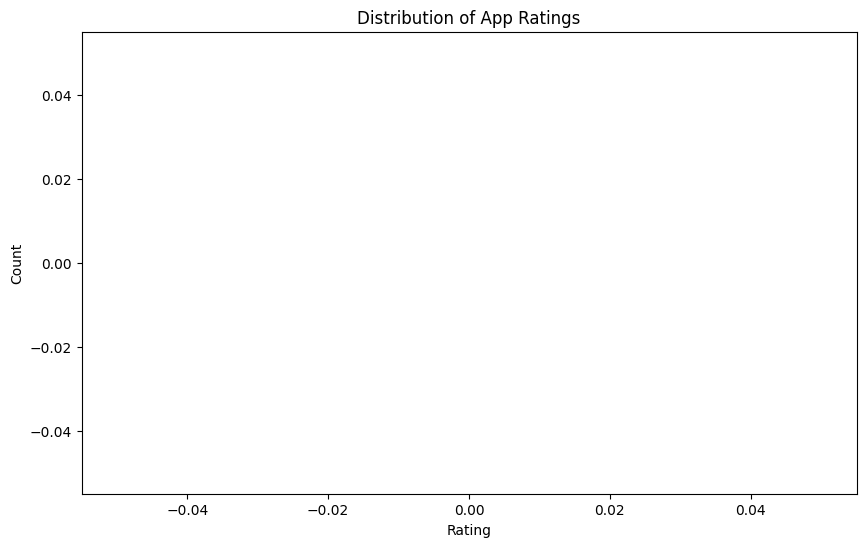

In [ ]:
# 3. Metrics Analysis

# Analyze app ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

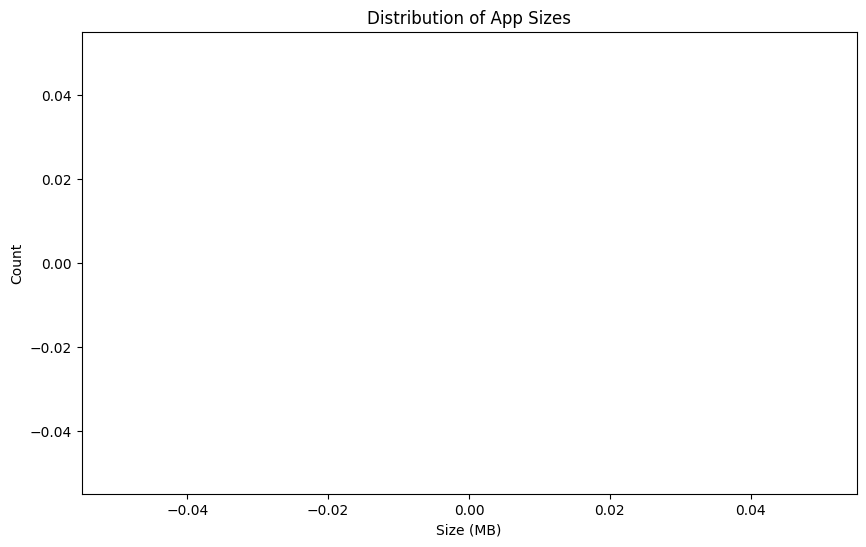

In [ ]:
# Analyze app size
plt.figure(figsize=(10, 6))
sns.histplot(df['Size'], bins=20, kde=True)
plt.title('Distribution of App Sizes')
plt.xlabel('Size (MB)')
plt.ylabel('Count')
plt.show()

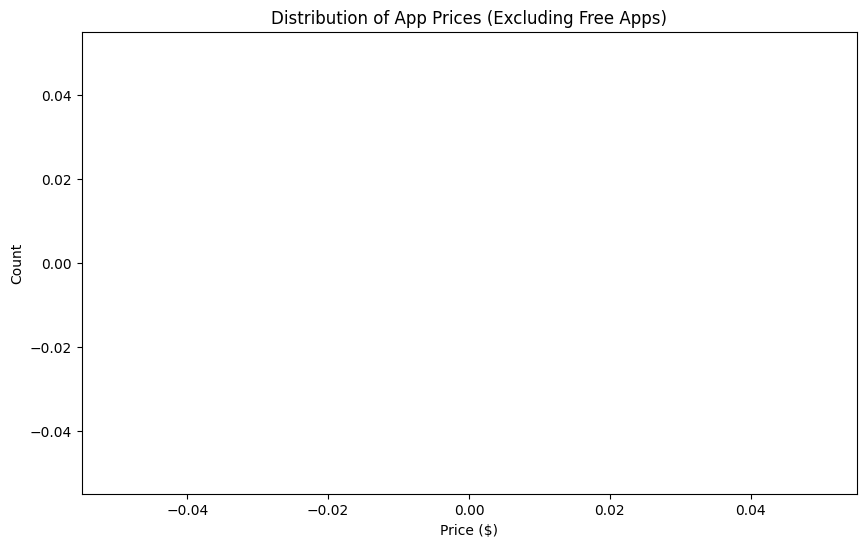

Metrics analysis completed.


In [ ]:
# Analyze app pricing
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Price'] > 0]['Price'], bins=20, kde=True)
plt.title('Distribution of App Prices (Excluding Free Apps)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

print("Metrics analysis completed.")

In [ ]:
# 4. Sentiment Analysis

# Function to perform sentiment analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [ ]:
# Load the reviews dataset
reviews_df = pd.read_csv('user_reviews.csv.zip')

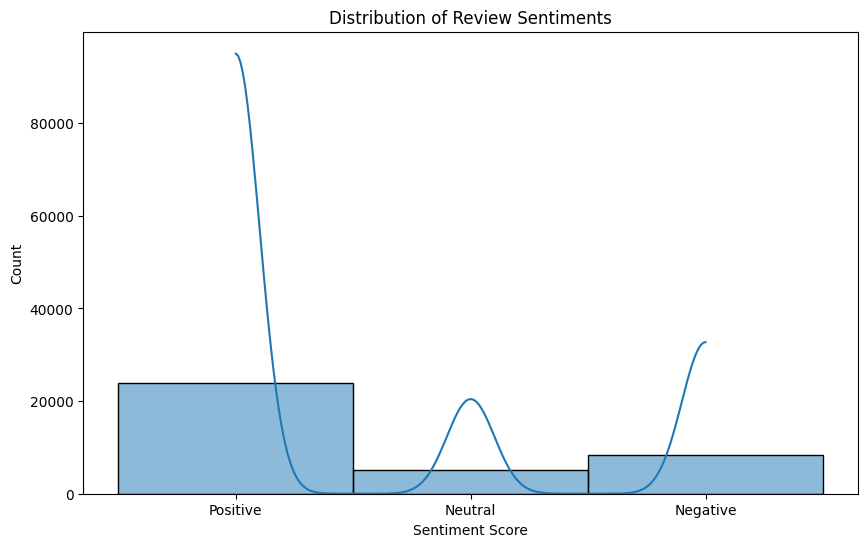

Sentiment analysis completed.


In [ ]:
# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(reviews_df['Sentiment'], bins=20, kde=True)
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

print("Sentiment analysis completed.")


In [ ]:
# 5. Interactive Visualization

# Create an interactive scatter plot of Rating vs. Reviews
fig = px.scatter(df, x='Reviews', y='Rating', color='Category',
                 hover_data=['App', 'Price'],
                 title='App Rating vs. Number of Reviews')
fig.show()

print("Interactive visualization created.")

Interactive visualization created.


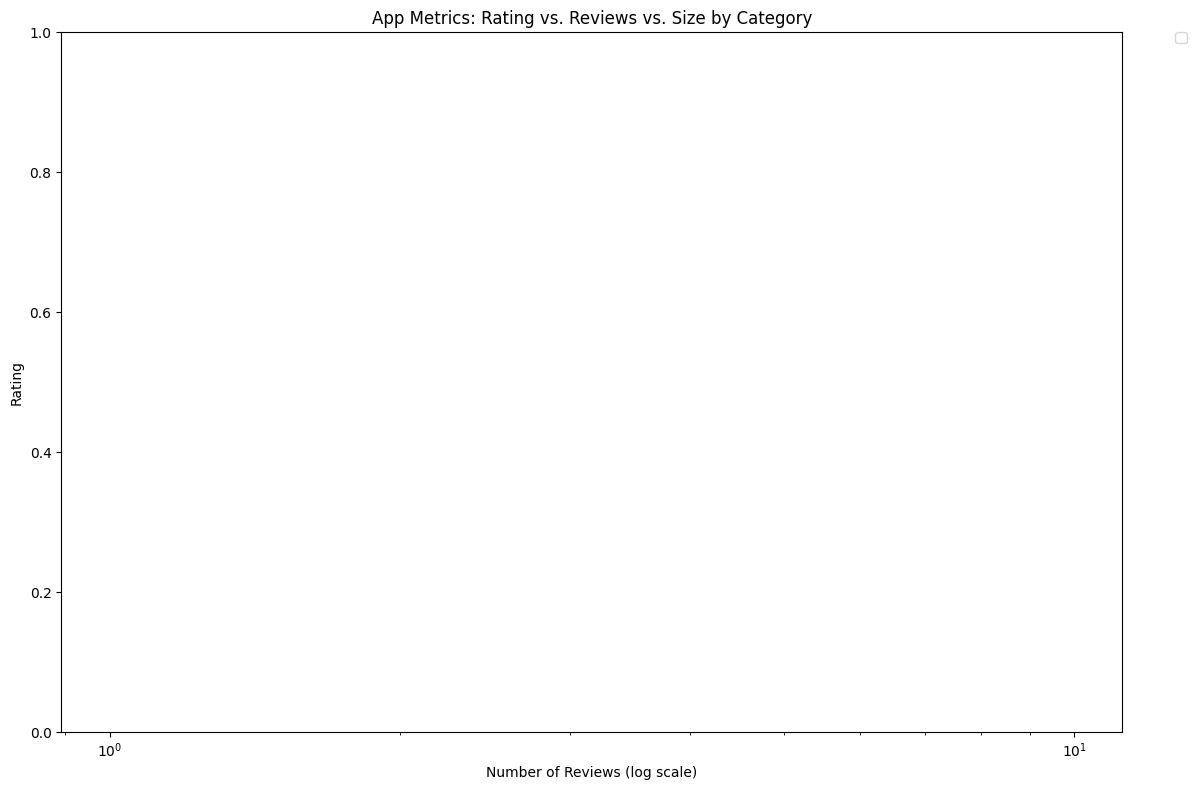

Enhanced visualization created.
Analysis complete. Don't forget to interpret the results and draw insights from the visualizations!


In [ ]:
# 6. Skill Enhancement

# Create a more complex visualization combining multiple metrics
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Reviews', y='Rating', hue='Category', size='Size',
                sizes=(20, 200), alpha=0.7)
plt.title('App Metrics: Rating vs. Reviews vs. Size by Category')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Rating')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

print("Enhanced visualization created.")

print("Analysis complete. Don't forget to interpret the results and draw insights from the visualizations!")
